# Importar librerías

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)

# Cargar recursos

In [3]:
# Ruta del archivo parquet donde se encuentran los resultados de la experimentación
OUTPUT_PATH = Path("../../outputs/runs/nbaiot_autoencoder_global_stage_3/test_predictions.parquet")

In [5]:
# Cargar los resultados en un dataframe de pandas
results_df = pd.read_parquet(OUTPUT_PATH)

A continuación, se cargan los recursos relacionados con las cuestiones de escalabilidad.

In [9]:
SCALABILITY_RESULTS_PATH = OUTPUT_PATH.parent / "global_summary.json"

scalability_df = pd.read_json(SCALABILITY_RESULTS_PATH, typ="series").to_frame().T

# Analizar resultados

## 1. Rendimiento global sobre el dataset de test completo

Una vez finalizado el proceso de optimización del autoencoder global y seleccionado el criterio de decisión durante el *Stage 2* de la experimentación, el siguiente paso consiste en evaluar el comportamiento del modelo sobre el conjunto de test completo. Para ello, se aplica el modelo entrenado al tráfico benigno y malicioso del conjunto de evaluación utilizando el threshold previamente seleccionado, sin realizar ningún ajuste adicional.

Con el objetivo de ofrecer una visión global del rendimiento del modelo, se presentan tanto la matriz de confusión como un conjunto de métricas de clasificación. Dado el elevado desbalance existente entre tráfico benigno y tráfico de ataque, se da prioridad a métricas poco sensibles a la distribución de las clases, como el **Recall (TPR)**, que mide la capacidad del modelo para detectar tráfico malicioso; la **False Positive Rate (FPR)**, que cuantifica la proporción de muestras benignas clasificadas erróneamente como ataques; la **Balanced Accuracy**, que calcula el promedio entre sensibilidad y especificidad, proporcionando una medida equilibrada del rendimiento; y el **Matthews Correlation Coefficient (MCC)**, que resume la calidad global de la clasificación considerando simultáneamente verdaderos y falsos positivos y negativos. Como información complementaria también se incluyen la **Precision**, el **F1-score**, la **Accuracy**, la **Specificity (TNR)** y la **False Negative Rate (FNR)**

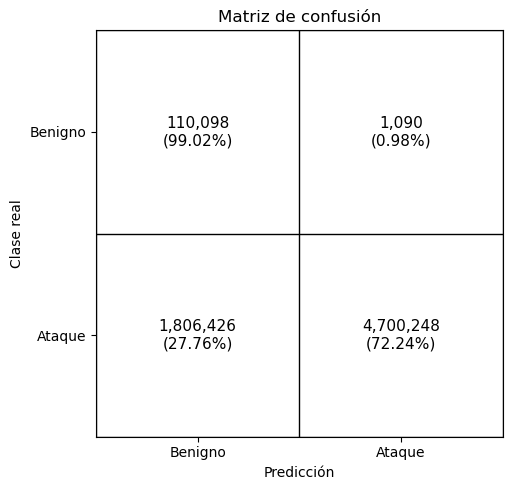

In [4]:
# Calcular la matriz de confusión y los porcentajes normalizados por fila
cm = confusion_matrix(results_df["y_true"], results_df["y_pred"])

cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

cm_labels = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        cm_labels[i, j] = f"{cm[i, j]:,}\n({cm_percent[i, j]:.2f}%)"


fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm_labels[i, j],
            ha="center",
            va="center",
            fontsize=11,
        )

# Dibujar líneas de la cuadrícula
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Benigno", "Ataque"])
ax.set_yticklabels(["Benigno", "Ataque"])

ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión")

plt.tight_layout()
plt.show()

In [5]:
# Tabal de métricas
tn, fp, fn, tp = cm.ravel()
y_true = results_df["y_true"].to_numpy()
y_pred = results_df["y_pred"].to_numpy()
metrics = pd.DataFrame(
    {
        "Métrica": [
            "Recall (TPR)",
            "False Positive Rate (FPR)",
            "Balanced Accuracy",
            "Matthews Correlation Coefficient (MCC)",
            "Precision",
            "F1-score",
            "Accuracy",
            "Specificity (TNR)",
            "False Negative Rate (FNR)",
        ],
        "Valor": [
            recall_score(y_true, y_pred),
            fp / (fp + tn),
            balanced_accuracy_score(y_true, y_pred),
            matthews_corrcoef(y_true, y_pred),
            precision_score(y_true, y_pred),
            f1_score(y_true, y_pred),
            accuracy_score(y_true, y_pred),
            tn / (tn + fp),
            fn / (fn + tp),
        ],
    }
)
metrics["Valor"] = metrics["Valor"].round(4)

display(metrics)

,Métrica,Valor
0,Recall (TPR),0.7224
1,False Positive Rate (FPR),0.0098
2,Balanced Accuracy,0.8563
3,Matthews Correlation Coefficient (MCC),0.2019
4,Precision,0.9998
5,F1-score,0.8387
6,Accuracy,0.7269
7,Specificity (TNR),0.9902
8,False Negative Rate (FNR),0.2776


Los resultados obtenidos muestran que el autoencoder global alcanza un **Recall (TPR) del 72.24 %**, lo que indica que aproximadamente siete de cada diez muestras maliciosas presentes en el conjunto de test son identificadas correctamente. Paralelamente, el modelo mantiene una **False Positive Rate (FPR) del 0.98 %**, reflejando una tasa de falsas alarmas inferior al 1 %, una característica especialmente relevante en sistemas de detección de intrusiones, donde un exceso de falsos positivos puede comprometer la operatividad del sistema.

Como consecuencia del equilibrio entre ambas magnitudes, la **Balanced Accuracy alcanza un valor de 85.63 %**, indicando un comportamiento global equilibrado tanto sobre la clase benigna como sobre la clase de ataque. Por su parte, el **Matthews Correlation Coefficient (MCC)** obtiene un valor de **0.2019**. Aunque este coeficiente presenta un valor moderado, debe interpretarse con cautela debido al fuerte desbalance existente entre ambas clases en el conjunto de evaluación, donde el número de muestras de ataque es muy superior al de muestras benignas.

Las métricas complementarias refuerzan esta interpretación. La **Precision**, con un valor de **99.98 %**, evidencia que prácticamente todas las muestras clasificadas como ataques corresponden realmente a tráfico malicioso, mientras que el **F1-score** alcanza un **83.87 %**, reflejando un compromiso entre la elevada precisión y una capacidad de detección más moderada. La **Specificity (TNR)**, del **99.02 %**, resulta coherente con la reducida tasa de falsas alarmas observada anteriormente, mientras que la **False Negative Rate (FNR)** del **27.76 %** representa el porcentaje de muestras de ataque que no han sido detectadas por el modelo.

Finalmente, aunque la **Accuracy** alcanza un **72.69 %**, esta métrica resulta menos representativa debido al acusado desbalance entre ambas clases, por lo que su interpretación debe realizarse con cautela.

En conjunto, estos resultados muestran que el autoencoder global es capaz de mantener una tasa muy reducida de falsas alarmas al mismo tiempo que detecta una parte significativa del tráfico malicioso. No obstante, el valor obtenido en Recall sugiere que la capacidad de detección podría no ser homogénea para todos los dispositivos o tipos de ataque presentes en el dataset. Esta hipótesis será analizada en detalle en los siguientes apartados mediante un estudio desagregado del rendimiento del modelo.

## 2. Rendimiento por dispositivo

Tras analizar el comportamiento global del autoencoder sobre el conjunto de test completo, resulta de interés estudiar cómo varía su rendimiento entre los distintos dispositivos IoT que componen el dataset N-BaIoT. Este análisis permite determinar si el modelo presenta un comportamiento homogéneo independientemente del dispositivo analizado o, por el contrario, existen diferencias significativas que puedan haber quedado ocultas en las métricas globales.

Para ello, se calculan las mismas métricas de clasificación presentadas en el apartado anterior de forma independiente para cada uno de los nueve dispositivos del dataset. Adicionalmente, se representa gráficamente el **Recall** de cada dispositivo junto con el valor medio obtenido entre todos ellos, ya que esta métrica resulta especialmente representativa en un sistema de detección de intrusiones al reflejar la capacidad del modelo para identificar correctamente el tráfico malicioso.

In [6]:
device_metrics = []

for device in sorted(results_df["device_id"].unique()):

    device_df = results_df[results_df["device_id"] == device]

    y_true = device_df["y_true"]
    y_pred = device_df["y_pred"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    device_metrics.append(
        {
            "Device": device,
            "Recall": recall_score(y_true, y_pred),
            "FPR": fp / (fp + tn),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "MCC": matthews_corrcoef(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "F1-score": f1_score(y_true, y_pred),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Specificity": tn / (tn + fp),
            "FNR": fn / (fn + tp),
        }
    )

device_metrics_df = pd.DataFrame(device_metrics)

display(device_metrics_df)

,Device,Recall,FPR,Balanced Accuracy,MCC,Precision,F1-score,Accuracy,Specificity,FNR
0,1,0.795595,0.000303,0.897646,0.194655,0.999996,0.886162,0.797662,0.999697,0.204405
1,2,0.757065,0.005719,0.875673,0.098281,0.999976,0.861729,0.757819,0.994281,0.242935
2,3,0.350670,0.000512,0.675079,0.113228,0.999964,0.519249,0.366319,0.999488,0.649330
3,4,0.785172,0.018261,0.883456,0.335678,0.999118,0.879318,0.792360,0.981739,0.214828
4,5,0.727797,0.001528,0.863135,0.201926,0.999966,0.842445,0.732119,0.998472,0.272203
5,6,0.737187,0.003350,0.866919,0.259512,0.999879,0.848670,0.743931,0.996650,0.262813
6,7,0.355035,0.009204,0.672916,0.126695,0.999164,0.523909,0.374918,0.990796,0.644965
7,8,0.764099,0.022003,0.871048,0.182423,0.999672,0.866154,0.766513,0.977997,0.235901
8,9,0.758046,0.010753,0.873647,0.118473,0.999933,0.862348,0.759127,0.989247,0.241954


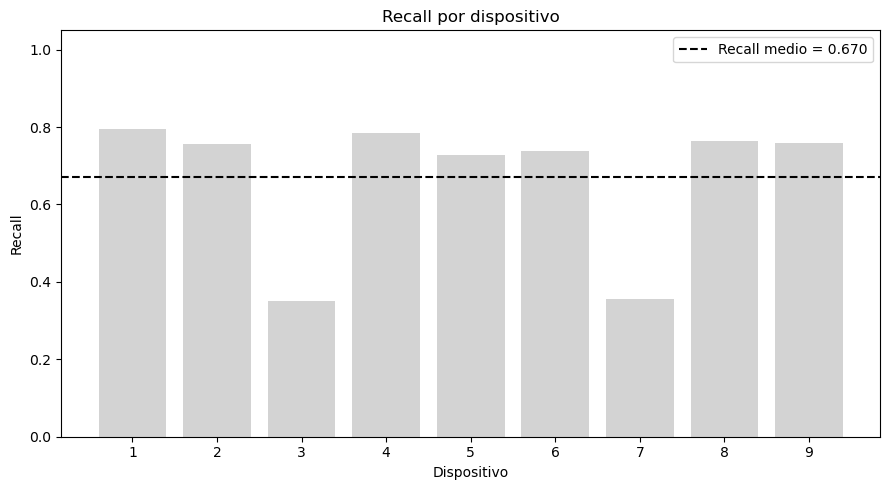

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    device_metrics_df["Device"].astype(str),
    device_metrics_df["Recall"],
    color="lightgray"
)

plt.axhline(
    device_metrics_df["Recall"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Recall medio = {device_metrics_df['Recall'].mean():.3f}",
    color="black"
)

plt.ylim(0, 1.05)

plt.xlabel("Dispositivo")
plt.ylabel("Recall")
plt.title("Recall por dispositivo")
plt.legend()

plt.tight_layout()
plt.show()

El análisis desagregado por dispositivo pone de manifiesto que el rendimiento del autoencoder global no es completamente homogéneo entre los distintos dispositivos del dataset. Mientras que siete de los nueve dispositivos presentan valores de **Recall** comprendidos aproximadamente entre el **72 %** y el **80 %**, los **dispositivos 3 y 7** muestran una capacidad de detección significativamente inferior, alcanzando valores de **35.07 %** y **35.50 %**, respectivamente. Estos dos dispositivos son los únicos que se sitúan claramente por debajo del **Recall medio**, fijado en **0.670**, lo que explica en gran medida el rendimiento global observado en el apartado anterior.

Esta reducción del Recall no viene acompañada de un incremento significativo de las falsas alarmas. En ambos dispositivos la **False Positive Rate (FPR)** se mantiene por debajo del **1 %**, concretamente en **0.05 %** para el dispositivo 3 y **0.92 %** para el dispositivo 7. Este comportamiento indica que el modelo continúa clasificando correctamente la inmensa mayoría del tráfico benigno incluso en aquellos dispositivos donde la capacidad de detección resulta considerablemente menor.

La **Balanced Accuracy** refleja la misma tendencia. Mientras que siete dispositivos alcanzan valores comprendidos entre **0.866** y **0.898**, los dispositivos **3** y **7** obtienen valores de **0.675** y **0.673**, respectivamente. Del mismo modo, tanto el **F1-score** como el **Matthews Correlation Coefficient (MCC)** experimentan una reducción apreciable en estos dos dispositivos como consecuencia directa de la disminución del Recall. Por el contrario, la **Precision** permanece prácticamente constante en todos los casos, con valores próximos al **100 %**, mientras que la **Specificity** supera el **97.7 %** para todos los dispositivos, confirmando que el modelo mantiene una elevada capacidad para reconocer correctamente el tráfico benigno independientemente del dispositivo analizado.

En conjunto, estos resultados muestran que el rendimiento del autoencoder global presenta diferencias apreciables entre dispositivos. No obstante, a partir de este análisis no es posible determinar si esta variabilidad está asociada a las características propias del tráfico generado por cada dispositivo o a la composición de los ataques presentes en su conjunto de evaluación. En consecuencia, resulta necesario analizar el comportamiento del modelo en función de la familia y del tipo de ataque antes de establecer conclusiones sobre el origen de estas diferencias de rendimiento.

## 3. Rendimiento por familia de ataque

In [8]:
attack_df = results_df[results_df["y_true"] == 1].copy()

### 3.1 Comparativa global por familia de ataque

En este primer análisis se agrupan todas las muestras de ataque según la familia de malware a la que pertenecen. De este modo, se obtiene una visión general del comportamiento del modelo frente a las 2 grandes categorías de ataques presentes en el dataset, permitiendo comprobar si ambas presentan un grado de dificultad similar o si existen diferencias significativas en su capacidad de detección.

In [9]:
family_metrics_df = (
    attack_df
    .groupby("attack_family")
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

family_metrics_df["false_negatives"] = (
    family_metrics_df["n_samples"] - family_metrics_df["true_positives"]
)

family_metrics_df["Recall"] = (
    family_metrics_df["true_positives"] / family_metrics_df["n_samples"]
)

family_metrics_df["FNR"] = (
    family_metrics_df["false_negatives"] / family_metrics_df["n_samples"]
)

family_metrics_df = family_metrics_df[
    [
        "attack_family",
        "n_samples",
        "true_positives",
        "false_negatives",
        "Recall",
        "FNR",
    ]
].sort_values("Recall", ascending=False)

display(family_metrics_df)

,attack_family,n_samples,true_positives,false_negatives,Recall,FNR
1,mirai,3668402,3667976,426,0.999884,0.000116
0,gafgyt,2838272,1032272,1806000,0.363697,0.636303


Los resultados muestran una diferencia muy marcada entre ambas familias de ataque. Mientras que el autoencoder global detecta prácticamente la totalidad de los ataques pertenecientes a la familia **Mirai**, alcanzando un **Recall del 99.99 %**, su capacidad de detección sobre la familia **Gafgyt** desciende hasta únicamente el **36.37 %**.

Estos resultados indican que la pérdida de rendimiento observada en el apartado anterior no afecta de manera uniforme a todo el tráfico malicioso, sino que se concentra de forma muy acusada en una de las dos familias de ataque presentes en el dataset. No obstante, dado que cada familia está formada por varios tipos de ataque con características diferentes, resulta necesario profundizar en el análisis para determinar si esta degradación afecta por igual a todos ellos o si existen ataques concretos responsables de este comportamiento.

### 3.2 Comparativa global por tipo de ataque

Con el objetivo de identificar el origen de las diferencias observadas entre familias de ataque, en este apartado se analiza el rendimiento del autoencoder para cada uno de los diez tipos de ataque presentes en el dataset N-BaIoT. Este análisis permite determinar si la menor capacidad de detección sobre la familia Gafgyt constituye un comportamiento generalizado o si, por el contrario, está motivada por un número reducido de tipos de ataque especialmente complejos.

In [11]:
type_metrics_df = (
    attack_df
    .groupby(["attack_family", "attack_type"])
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

type_metrics_df["false_negatives"] = (
    type_metrics_df["n_samples"] - type_metrics_df["true_positives"]
)

type_metrics_df["Recall"] = (
    type_metrics_df["true_positives"] / type_metrics_df["n_samples"]
)

type_metrics_df["FNR"] = (
    type_metrics_df["false_negatives"] / type_metrics_df["n_samples"]
)

type_metrics_df["attack_label"] = (
    type_metrics_df["attack_family"].astype(str)
    + " - "
    + type_metrics_df["attack_type"].astype(str)
)

type_metrics_df = type_metrics_df[
    [
        "attack_family",
        "attack_type",
        "attack_label",
        "n_samples",
        "true_positives",
        "false_negatives",
        "Recall",
        "FNR",
    ]
].sort_values("Recall", ascending=True)

display(type_metrics_df)

,attack_family,attack_type,attack_label,n_samples,true_positives,false_negatives,Recall,FNR
4,gafgyt,udp,gafgyt - udp,946366,261,946105,0.000276,0.999724
3,gafgyt,tcp,gafgyt - tcp,859850,252,859598,0.000293,0.999707
6,mirai,scan,mirai - scan,537979,537737,242,0.999550,0.000450
2,gafgyt,scan,gafgyt - scan,255111,255004,107,0.999581,0.000419
1,gafgyt,junk,gafgyt - junk,261789,261688,101,0.999614,0.000386
0,gafgyt,combo,gafgyt - combo,515156,515067,89,0.999827,0.000173
7,mirai,syn,mirai - syn,733299,733213,86,0.999883,0.000117
8,mirai,udp,mirai - udp,1229999,1229938,61,0.999950,0.000050
5,mirai,ack,mirai - ack,643821,643797,24,0.999963,0.000037
9,mirai,udpplain,mirai - udpplain,523304,523291,13,0.999975,0.000025


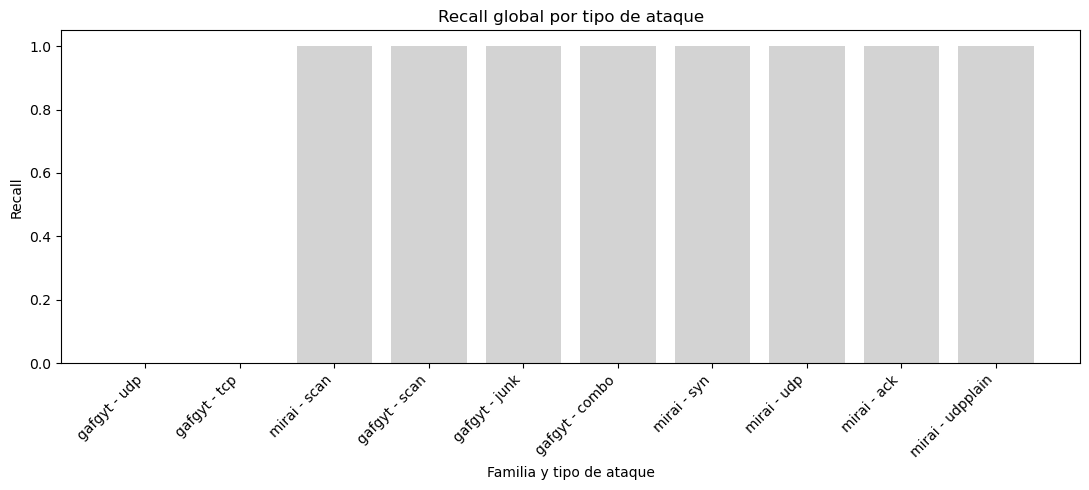

In [12]:
plt.figure(figsize=(11, 5))

type_metrics_df = type_metrics_df.sort_values("Recall", ascending=True)
plt.bar(
    type_metrics_df["attack_label"],
    type_metrics_df["Recall"],
    color="lightgray"
)

plt.ylim(0, 1.05)

plt.xlabel("Familia y tipo de ataque")
plt.ylabel("Recall")
plt.title("Recall global por tipo de ataque")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

El análisis por tipo de ataque revela que la pérdida de rendimiento observada sobre la familia **Gafgyt** no constituye un comportamiento homogéneo. De hecho, 3 de sus 5 tipos de ataque (**Combo**, **Junk** y  **Scan**) alcanzan valores de **Recall superiores al 99.95 %**, comparables a los obtenidos por todos los ataques pertenecientes a la familia **Mirai**.

Sin embargo, los ataques **Gafgyt UDP** y **Gafgyt TCP** presentan un comportamiento completamente diferente. Ambos obtienen un **Recall prácticamente nulo**, con valores de **0.0276 %** y **0.0293 %**, respectivamente. En consecuencia, sus correspondientes **False Negative Rate** alcanzan prácticamente el **100 %**, indicando que casi todas las muestras pertenecientes a estos dos ataques son clasificadas erróneamente como tráfico benigno.

Este resultado explica prácticamente en su totalidad la diferencia observada entre ambas familias de ataque. La baja capacidad de detección sobre **Gafgyt** no se debe a que el modelo tenga dificultades generalizadas con dicha familia, sino a que dos tipos concretos de ataque concentran prácticamente todos los errores de clasificación.

Asimismo, este comportamiento permite interpretar con mayor claridad los resultados obtenidos en el apartado anterior. Los dispositivos **3** y **7**, que presentaban los menores valores de Recall, contienen exclusivamente ataques de la familia **Gafgyt**. Dado que una parte importante de las muestras de ataque de estos dispositivos corresponde precisamente a los ataques **UDP** y **TCP**, la reducción del Recall observada previamente puede explicarse por la elevada dificultad que presenta el modelo para detectar estos dos tipos de ataque, y no necesariamente por las características propias del dispositivo.

En conjunto, este análisis identifica con claridad el principal punto débil del autoencoder global: la detección de los ataques **Gafgyt UDP** y **Gafgyt TCP**. Por el contrario, el resto de tipos de ataque presentes en el dataset son detectados prácticamente en su totalidad, alcanzando valores de Recall próximos al 100 %.

## 4. Análisis de margen de mejora mediante ajuste supervisado del *threshold*

Los apartados anteriores han puesto de manifiesto que el autoencoder global presenta una elevada capacidad para detectar la mayoría de los tipos de ataque, aunque mantiene dificultades significativas frente a determinados ataques pertenecientes a la familia **Gafgyt**, especialmente los tipos **UDP** y **TCP**. Una posible explicación de este comportamiento es que el criterio de decisión seleccionado durante el *Stage 2* resulte excesivamente conservador y, por tanto, clasifique como benignas numerosas muestras maliciosas cuyos errores de reconstrucción se sitúan por debajo del *threshold* establecido.

Con el objetivo de estimar el margen de mejora potencial asociado únicamente al criterio de decisión, en este apartado se realiza un estudio supervisado utilizando las etiquetas reales del conjunto de test para determinar el *threshold* que maximiza el rendimiento del modelo. Este análisis no pretende proponer un nuevo criterio de selección, ya que emplea información que no estaría disponible en un escenario real de despliegue, sino evaluar hasta qué punto las limitaciones observadas pueden atribuirse al *threshold* seleccionado durante la experimentación o, por el contrario, a un solapamiento inherente entre las distribuciones de tráfico benigno y malicioso.

In [1]:
CURRENT_THRESHOLD = 0.5562

def find_optimal_threshold_by_mcc(
    y_true,
    scores,
    n_candidates=2000,
    min_quantile=0.0,
    max_quantile=1.0,
):
    """
    Calcula un threshold aproximado maximizando MCC sobre una rejilla de cuantiles.
    Se asume que mayor score implica mayor anomalía.
    """

    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    quantiles = np.linspace(min_quantile, max_quantile, n_candidates)
    candidate_thresholds = np.quantile(scores, quantiles)
    candidate_thresholds = np.unique(candidate_thresholds)

    best_threshold = None
    best_mcc = -np.inf

    for th in tqdm(candidate_thresholds):
        y_pred = (scores > th).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_threshold = th

    return {
        "threshold": best_threshold,
        "mcc": best_mcc,
    }


def compute_binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FPR": fp / (fp + tn),
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

In [6]:
y_true = results_df["y_true"].astype(int).to_numpy()
errors = results_df["reconstruction_error"].to_numpy()

optimal_info = find_optimal_threshold_by_mcc(y_true, errors, n_candidates=100, min_quantile=0.0, max_quantile=0.5)
optimal_th = optimal_info["threshold"]

100%|██████████| 48/48 [01:01<00:00,  1.29s/it]


In [8]:
threshold_rows = []
for device in sorted(results_df["device_id"].unique()):
    device_df = results_df[results_df["device_id"] == device].copy()

    y_true = device_df["y_true"].astype(int).to_numpy()
    errors = device_df["reconstruction_error"].to_numpy()

    y_pred_current = (errors > CURRENT_THRESHOLD).astype(int)
    y_pred_optimal = (errors > optimal_th).astype(int)

    current_metrics = compute_binary_metrics(y_true, y_pred_current)
    optimal_metrics = compute_binary_metrics(y_true, y_pred_optimal)

    threshold_rows.append({
        "device": device,
        "current_threshold": CURRENT_THRESHOLD,
        "optimal_threshold": optimal_th,

        "current_recall": current_metrics["Recall"],
        "optimal_recall": optimal_metrics["Recall"],

        "current_fpr": current_metrics["FPR"],
        "optimal_fpr": optimal_metrics["FPR"],

        "current_precision": current_metrics["Precision"],
        "optimal_precision": optimal_metrics["Precision"],

        "current_mcc": current_metrics["MCC"],
        "optimal_mcc": optimal_metrics["MCC"],
    })

threshold_analysis_df = pd.DataFrame(threshold_rows)

display(threshold_analysis_df.round(4))

,device,current_threshold,optimal_threshold,current_recall,optimal_recall,current_fpr,optimal_fpr,current_precision,optimal_precision,current_mcc,optimal_mcc
0,1,0.5562,0.0643,0.7956,1.0,0.0003,0.0080,1.0000,0.9999,0.1947,0.9953
1,2,0.5562,0.0643,0.7571,1.0,0.0057,0.2009,1.0000,0.9994,0.0983,0.8909
2,3,0.5562,0.0643,0.3507,1.0,0.0005,0.0962,1.0000,0.9976,0.1132,0.9487
3,4,0.5562,0.0643,0.7852,1.0,0.0183,0.0851,0.9991,0.9968,0.3357,0.9548
4,5,0.5562,0.0643,0.7278,1.0,0.0015,0.0644,1.0000,0.9990,0.2019,0.9662
5,6,0.5562,0.0643,0.7372,1.0,0.0033,0.1657,0.9999,0.9956,0.2595,0.9110
6,7,0.5562,0.0643,0.3550,1.0,0.0092,0.0919,0.9992,0.9970,0.1267,0.9509
7,8,0.5562,0.0643,0.7641,1.0,0.0220,0.1412,0.9997,0.9984,0.1824,0.9252
8,9,0.5562,0.0643,0.7580,1.0,0.0108,0.0909,0.9999,0.9996,0.1185,0.9515


In [ ]:
def assign_score_group(row):
    if row["y_true"] == 0:
        return "Benigno"

    if row["attack_family"] == "gafgyt" and row["attack_type"] in ["tcp", "udp"]:
        return "Gafgyt TCP/UDP"

    return "Resto de ataques"


plot_df = results_df.copy()
plot_df["score_group"] = plot_df.apply(assign_score_group, axis=1)


COLOR_GROUPS = [
    ("Benigno", "tab:blue", 0.45),
    ("Gafgyt TCP/UDP", "tab:red", 0.45),
    ("Resto de ataques", "lightcoral", 0.35),
]

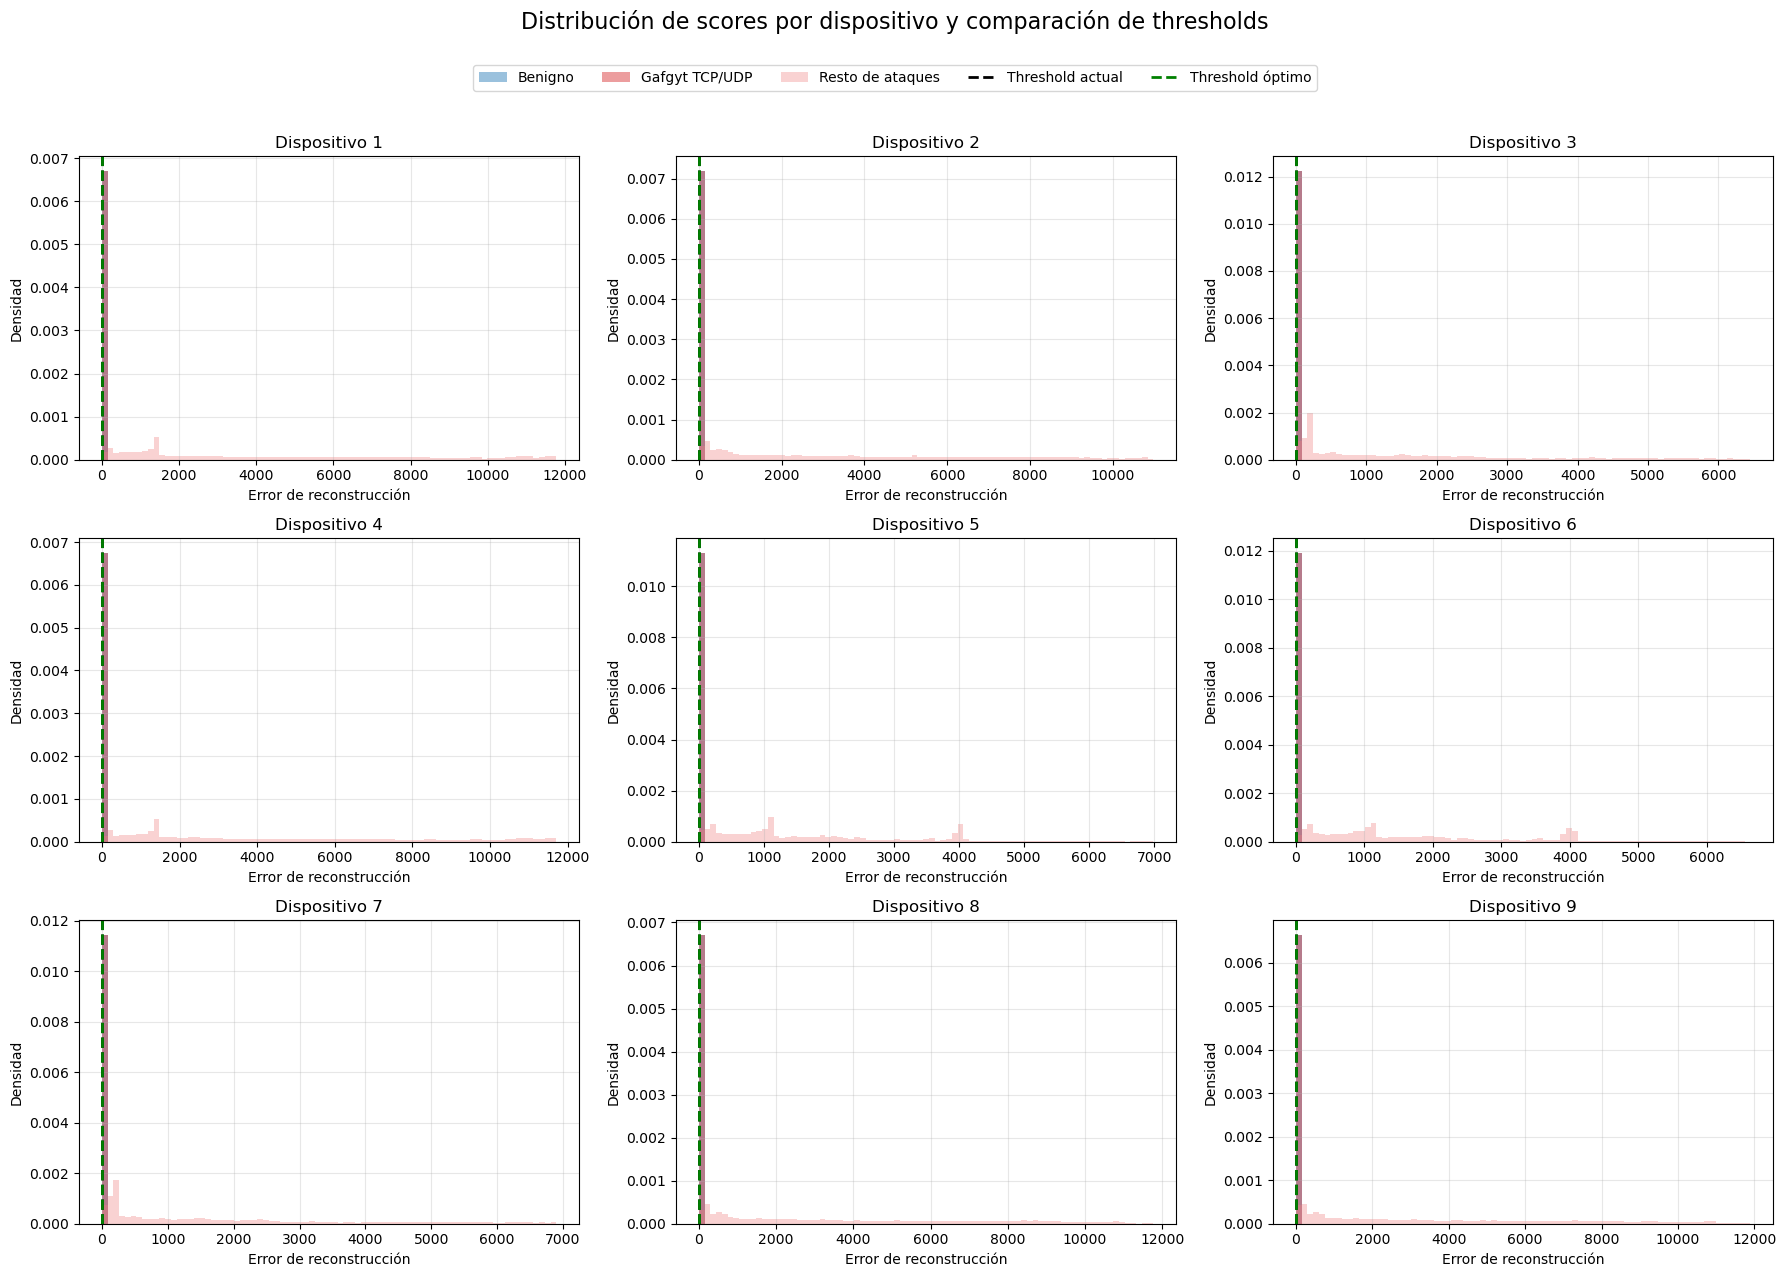

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, device in zip(axes, sorted(plot_df["device_id"].unique())):
    device_df = plot_df[plot_df["device_id"] == device]

    current_th = CURRENT_THRESHOLD
    optimal_th = threshold_analysis_df[
        "optimal_threshold"
    ].iloc[0]

    max_error_for_plot = np.quantile(device_df["reconstruction_error"], 0.995)
    max_error_for_plot = max(max_error_for_plot, current_th, optimal_th)

    bins = np.linspace(0, max_error_for_plot, 80)

    for group_name, color, alpha in COLOR_GROUPS:
        values = device_df.loc[
            device_df["score_group"] == group_name,
            "reconstruction_error"
        ]

        if len(values) == 0:
            continue

        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=alpha,
            color=color,
            label=group_name,
        )

    ax.axvline(
        current_th,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Threshold actual",
    )

    ax.axvline(
        optimal_th,
        color="green",
        linestyle="--",
        linewidth=2,
        label="Threshold óptimo",
    )

    ax.set_title(f"Dispositivo {device}")
    ax.set_xlabel("Error de reconstrucción")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Distribución de errores de reconstrucción por dispositivo y comparación de thresholds",
    fontsize=16,
    y=1.06,
)

fig.tight_layout()
plt.show()

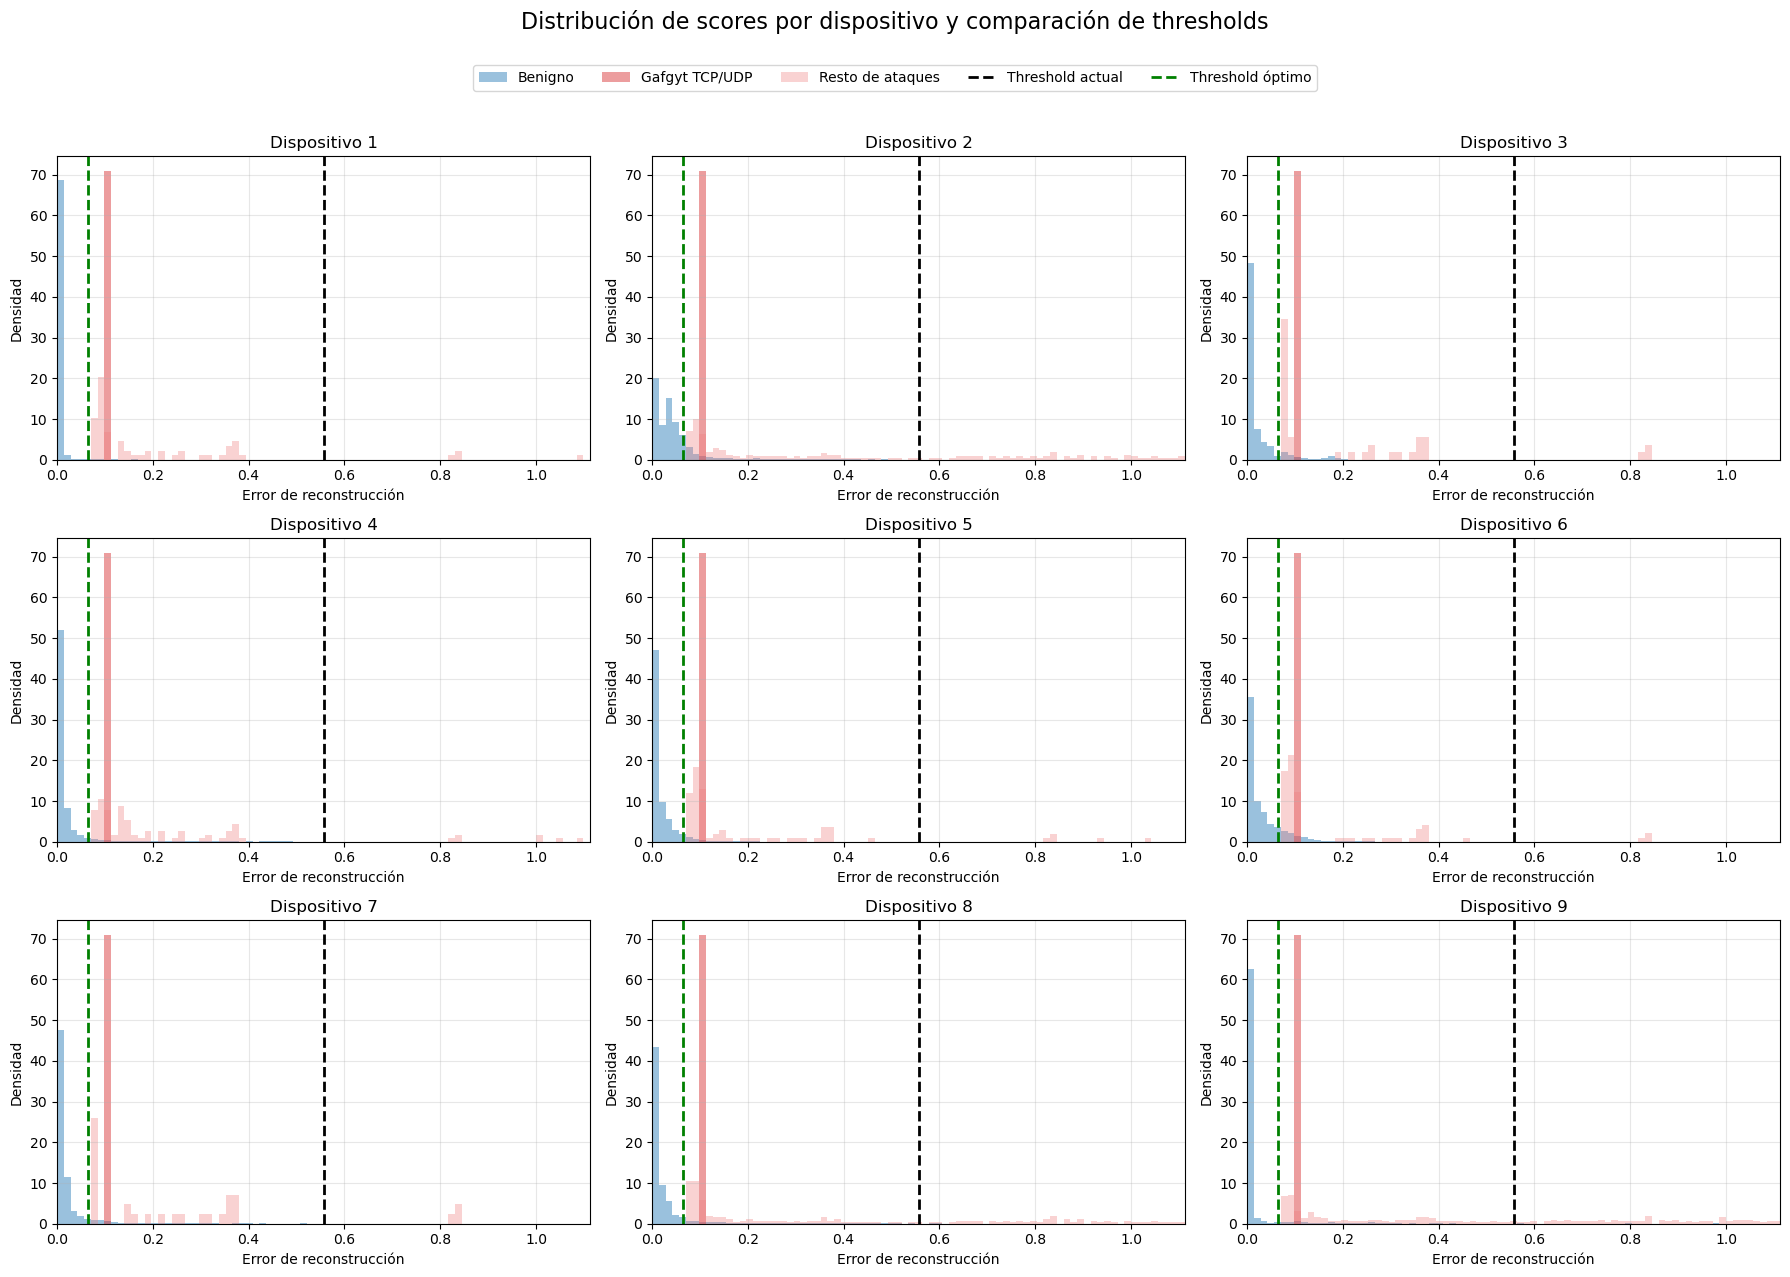

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, device in zip(axes, sorted(plot_df["device_id"].unique())):
    device_df = plot_df[plot_df["device_id"] == device]

    current_th = CURRENT_THRESHOLD
    optimal_th = threshold_analysis_df[
        "optimal_threshold"
    ].iloc[0]

    max_error_for_plot = max(current_th * 2, optimal_th * 2)

    bins = np.linspace(0, max_error_for_plot, 80)

    for group_name, color, alpha in COLOR_GROUPS:
        values = device_df.loc[
            device_df["score_group"] == group_name,
            "reconstruction_error"
        ]

        if len(values) == 0:
            continue

        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=alpha,
            color=color,
            label=group_name,
        )

        ax.set_xlim(0,max_error_for_plot)

    ax.axvline(
        current_th,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Threshold actual",
    )

    ax.axvline(
        optimal_th,
        color="green",
        linestyle="--",
        linewidth=2,
        label="Threshold óptimo",
    )

    ax.set_title(f"Dispositivo {device}")
    ax.set_xlabel("Error de reconstrucción")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Distribución de errores de reconstrucción ampliados por dispositivo y comparación de thresholds",
    fontsize=16,
    y=1.06,
)

fig.tight_layout()
plt.show()

Los resultados obtenidos muestran que el margen de mejora del autoencoder global es considerable cuando se permite ajustar el *threshold* utilizando las etiquetas reales del conjunto de test. En todos los dispositivos, el *threshold* óptimo coincide en el valor **0.0643**, muy inferior al valor **0.5562** seleccionado durante el *Stage 2* mediante un criterio completamente no supervisado. Como consecuencia, el **Recall** alcanza el **100 %** en los nueve dispositivos analizados, eliminando por completo los falsos negativos observados en la evaluación anterior.

Esta mejora en la capacidad de detección viene acompañada de un incremento de la **False Positive Rate (FPR)**, cuyo valor pasa de situarse por debajo del **2.3 %** en todos los dispositivos a alcanzar valores comprendidos entre el **0.80 %** y el **20.09 %**, dependiendo del dispositivo. A pesar de este aumento, la **Precision** continúa siendo muy elevada en todos los casos, con valores superiores al **99.5 %**, mientras que el **Matthews Correlation Coefficient (MCC)** experimenta una mejora muy significativa, alcanzando valores próximos o superiores a **0.90** para todos los dispositivos.

La comparación entre ambos *thresholds* resulta especialmente esclarecedora al analizar la distribución de los errores de reconstrucción. Al ampliar la región donde se concentran las muestras benignas y los ataques con menores errores de reconstrucción, se observa que el *threshold* seleccionado durante el *Stage 2* queda situado claramente a la derecha de una parte importante de las muestras correspondientes a los ataques **Gafgyt UDP** y **Gafgyt TCP**, provocando que estas sean clasificadas como tráfico benigno. En cambio, el *threshold* óptimo se desplaza hacia una zona donde consigue recuperar prácticamente todas estas muestras, incrementando la capacidad de detección a costa de aceptar un mayor número de falsas alarmas.

Un resultado especialmente relevante es que el *threshold* óptimo obtenido es idéntico para los nueve dispositivos del dataset. Este hecho indica que el margen de mejora observado no requiere introducir criterios de decisión específicos para cada dispositivo, sino que puede alcanzarse mediante un único *threshold* global. En consecuencia, la pérdida de rendimiento observada anteriormente no parece estar asociada a una falta de homogeneidad entre dispositivos, sino al compromiso inherente entre sensibilidad y tasa de falsas alarmas impuesto por el criterio de selección del *threshold* empleado durante la experimentación.

En conjunto, este análisis demuestra que una parte importante de las limitaciones observadas en el autoencoder global no proviene de la capacidad representativa del modelo, sino de la posición del *threshold* utilizada para discriminar entre tráfico benigno y malicioso. No obstante, dado que este estudio utiliza las etiquetas reales del conjunto de test para optimizar el criterio de decisión, sus resultados deben interpretarse únicamente como una estimación del margen de mejora potencial y no como un procedimiento aplicable en un entorno real de detección de anomalías.

## 5. Sensibilidad frente a prevalencia de ataque

In [9]:
ATTACK_PREVALENCES = [
    0.10,
    0.05,
    0.01,
    0.005,
    0.001,
]

N_REPEATS = 30

RANDOM_STATE = 42

def compute_metrics(df):

    y_true = df["y_true"]
    y_pred = df["y_pred"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FPR": fp / (fp + tn),
    }

### 5.1 Thresholds no supervisados (propuesta final)

Las métricas obtenidas en los apartados anteriores se han calculado utilizando la distribución original del conjunto de test del dataset N-BaIoT. Sin embargo, dicha distribución no resulta representativa de un entorno IoT real, donde la inmensa mayoría del tráfico corresponde a actividad legítima y únicamente una pequeña fracción está asociada a ataques.

Con el objetivo de evaluar el comportamiento de la estrategia propuesta en escenarios más próximos a un despliegue real, en este apartado se analiza la sensibilidad del autoencoder global frente a distintas prevalencias de ataque. Para ello, se mantiene fijo el modelo final y el *threshold* seleccionado durante la experimentación, generando múltiples conjuntos de evaluación con prevalencias comprendidas entre el **0.1 %** y el **10 %** de tráfico malicioso. Sobre cada uno de ellos se calculan la **Precision**, el **Recall**, la **False Positive Rate (FPR)** y el **Matthews Correlation Coefficient (MCC)**, repitiendo el proceso varias veces para estimar tanto el valor medio como la variabilidad de cada métrica.

In [10]:
benign_df = results_df[results_df["y_true"] == 0].copy()
attack_df = results_df[results_df["y_true"] == 1].copy()

In [11]:
rng = np.random.default_rng(RANDOM_STATE)

all_results = []
n_benign = len(benign_df)
for prevalence in ATTACK_PREVALENCES:

    n_attack = int(
        prevalence / (1 - prevalence) * n_benign
    )

    for repeat in range(N_REPEATS):

        sampled_attack = attack_df.sample(
            n=n_attack,
            replace=False,
            random_state=rng.integers(0, 1_000_000),
        )

        evaluation_df = pd.concat(
            [benign_df, sampled_attack],
            ignore_index=True,
        )

        metrics = compute_metrics(evaluation_df)

        metrics["Attack prevalence"] = prevalence
        metrics["Repeat"] = repeat

        all_results.append(metrics)

prevalence_results = pd.DataFrame(all_results)

In [12]:
summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
)

summary = summary.round(4)

display(summary)

Precision          Recall             FPR          MCC  \
                       mean     std    mean     std    mean  std    mean   
Attack prevalence                                                          
0.001                0.0674  0.0032  0.7099  0.0360  0.0098  0.0  0.2168   
0.005                0.2698  0.0040  0.7220  0.0147  0.0098  0.0  0.4372   
0.010                0.4261  0.0048  0.7208  0.0140  0.0098  0.0  0.5486   
0.050                0.7951  0.0012  0.7228  0.0053  0.0098  0.0  0.7460   
0.100                0.8911  0.0006  0.7221  0.0047  0.0098  0.0  0.7830   

                           
                      std  
Attack prevalence          
0.001              0.0108  
0.005              0.0079  
0.010              0.0086  
0.050              0.0035  
0.100              0.0031

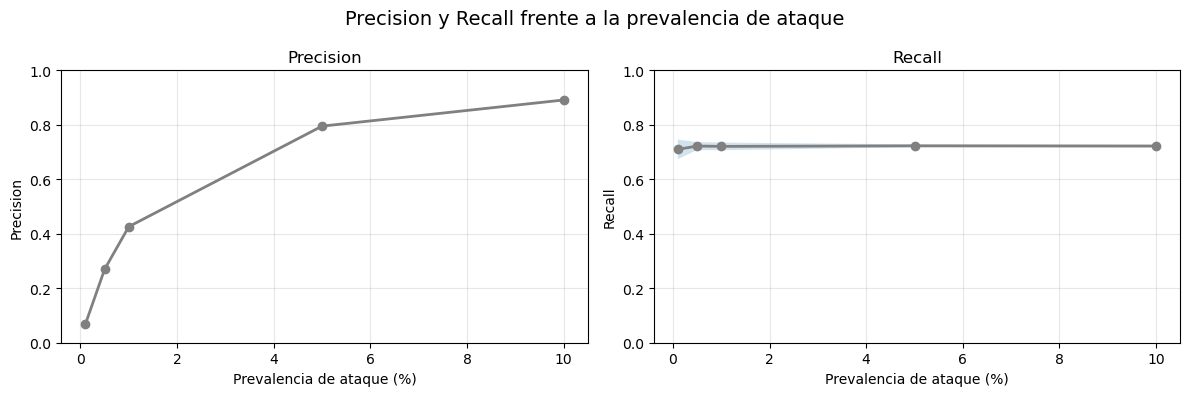

In [13]:
plot_summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
    .sort_index()
)

prevalence_values = plot_summary.index.to_numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["Precision", "Recall"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle("Precision y Recall frente a la prevalencia de ataque", fontsize=14)
fig.tight_layout()
plt.show()

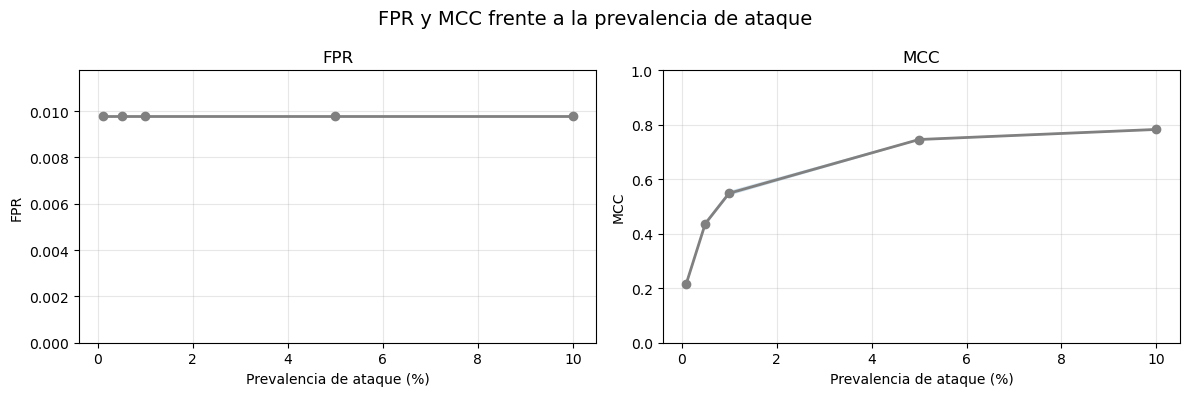

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["FPR", "MCC"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    if metric == "FPR":
        ax.set_ylim(0, max((mean_values + std_values).max() * 1.2, 0.01))
    else:
        ax.set_ylim(0, 1)

fig.suptitle("FPR y MCC frente a la prevalencia de ataque", fontsize=14)
fig.tight_layout()
plt.show()

Los resultados muestran que el comportamiento del autoencoder global permanece prácticamente invariable para aquellas métricas que dependen únicamente de la capacidad discriminativa del modelo. Tanto el **Recall** como la **False Positive Rate (FPR)** mantienen valores prácticamente constantes para todas las prevalencias analizadas, situándose en torno al **72 %** y **0.98 %**, respectivamente. Además, las reducidas desviaciones estándar obtenidas indican que estas métricas presentan una elevada estabilidad frente al proceso de remuestreo realizado.

Por el contrario, la **Precision** experimenta una evolución claramente dependiente de la prevalencia del ataque. Cuando únicamente el **0.1 %** del tráfico corresponde a muestras maliciosas, la Precision desciende hasta **0.067**, lo que implica que una proporción importante de las alarmas generadas corresponde en realidad a falsos positivos. A medida que aumenta la prevalencia del ataque, esta métrica mejora progresivamente, alcanzando valores de **0.891** para una prevalencia del **10 %**.

El **Matthews Correlation Coefficient (MCC)** presenta un comportamiento similar. Con prevalencias muy reducidas, el elevado número de muestras benignas hace que incluso una tasa de falsas alarmas inferior al **1 %** tenga un impacto considerable sobre esta métrica. En consecuencia, el MCC aumenta de forma progresiva desde **0.217** para una prevalencia del **0.1 %** hasta **0.783** cuando el **10 %** del tráfico corresponde a ataques.

En conjunto, estos resultados ponen de manifiesto que el rendimiento intrínseco del autoencoder global permanece estable independientemente de la prevalencia del ataque, tal y como refleja la invariabilidad del Recall y de la FPR. No obstante, las métricas que dependen explícitamente de la distribución de las clases, como la Precision y el MCC, experimentan variaciones significativas en escenarios con prevalencias muy reducidas. Este comportamiento resulta esperable y pone de relieve la importancia de interpretar dichas métricas considerando siempre el contexto operativo en el que vaya a desplegarse el sistema de detección de anomalías.

### 5.2 Análisis de la robustez de una estrategia de recalibración supervisada del threshold

En el apartado anterior se ha evaluado el comportamiento de la estrategia finalmente propuesta, basada en un *threshold* obtenido mediante un criterio completamente no supervisado a partir del conjunto de validación benigno. Sin embargo, el análisis realizado en el apartado 4 puso de manifiesto que un ajuste supervisado del *threshold* utilizando muestras etiquetadas permite incrementar significativamente la capacidad de detección del modelo.

Partiendo de esta observación, en este apartado se estudia la robustez de una estrategia basada en recalibrar dicho *threshold* utilizando una muestra etiquetada representativa del entorno de despliegue. En concreto, se analiza cómo varía el rendimiento del modelo frente a diferentes prevalencias de ataque cuando el *threshold* ha sido ajustado previamente mediante información supervisada. El objetivo no es comparar directamente esta estrategia con la propuesta final, sino evaluar hasta qué punto un *threshold* calibrado de esta forma mantiene un comportamiento estable ante cambios en la distribución de los datos.

In [16]:
optimal_results_df = results_df.copy()
optimal_results_df["y_pred"] = optimal_results_df.apply(lambda row: int(row["reconstruction_error"] > optimal_th), axis=1)

optimal_benign_df = optimal_results_df[optimal_results_df["y_true"] == 0].copy()
optimal_attack_df = optimal_results_df[optimal_results_df["y_true"] == 1].copy()

In [17]:
rng = np.random.default_rng(RANDOM_STATE)

all_results = []
n_benign = len(optimal_benign_df)
for prevalence in ATTACK_PREVALENCES:

    n_attack = int(
        prevalence / (1 - prevalence) * n_benign
    )

    for repeat in range(N_REPEATS):

        sampled_attack = optimal_attack_df.sample(
            n=n_attack,
            replace=False,
            random_state=rng.integers(0, 1_000_000),
        )

        evaluation_df = pd.concat(
            [optimal_benign_df, sampled_attack],
            ignore_index=True,
        )

        metrics = compute_metrics(evaluation_df)

        metrics["Attack prevalence"] = prevalence
        metrics["Repeat"] = repeat

        all_results.append(metrics)

prevalence_results = pd.DataFrame(all_results)

In [18]:
summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
)

summary = summary.round(4)

display(summary)

Precision       Recall             FPR          MCC        
                       mean  std    mean     std    mean  std    mean     std
Attack prevalence                                                            
0.001                0.0100  0.0  1.0000  0.0000  0.0992  0.0  0.0947  0.0000
0.005                0.0481  0.0  0.9999  0.0003  0.0992  0.0  0.2082  0.0001
0.010                0.0924  0.0  1.0000  0.0000  0.0992  0.0  0.2885  0.0000
0.050                0.3466  0.0  1.0000  0.0001  0.0992  0.0  0.5587  0.0000
0.100                0.5282  0.0  1.0000  0.0000  0.0992  0.0  0.6898  0.0000

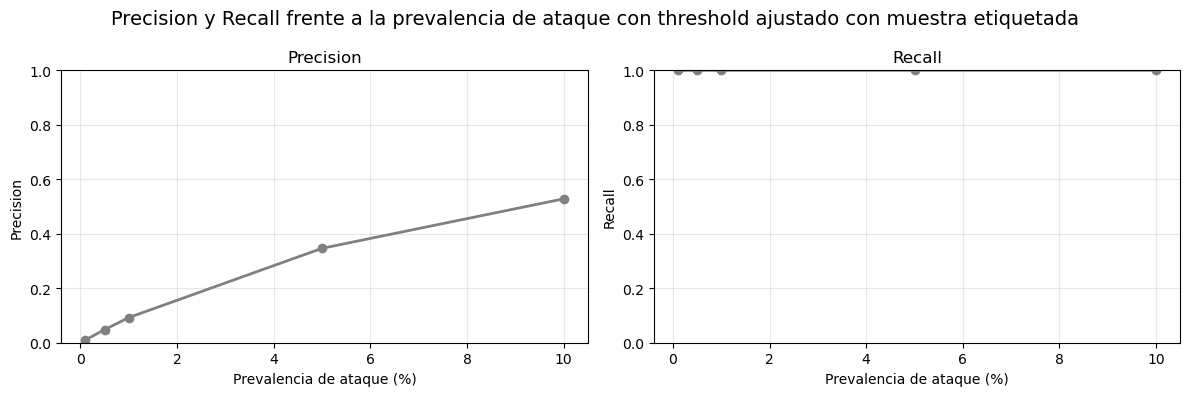

In [19]:
plot_summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
    .sort_index()
)

prevalence_values = plot_summary.index.to_numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["Precision", "Recall"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle("Precision y Recall frente a la prevalencia de ataque con threshold ajustado con muestra etiquetada", fontsize=14)
fig.tight_layout()

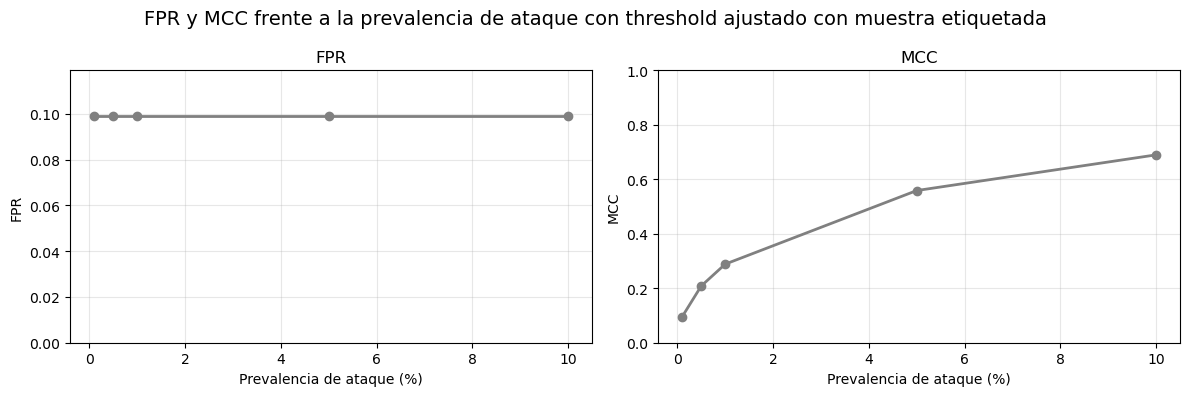

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["FPR", "MCC"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    if metric == "FPR":
        ax.set_ylim(0, max((mean_values + std_values).max() * 1.2, 0.01))
    else:
        ax.set_ylim(0, 1)

fig.suptitle("FPR y MCC frente a la prevalencia de ataque con threshold ajustado con muestra etiquetada", fontsize=14)
fig.tight_layout()
plt.show()

Los resultados obtenidos muestran que el *threshold* ajustado mediante información supervisada mantiene un comportamiento muy estable frente a las distintas prevalencias de ataque analizadas. Tanto el **Recall** como la **False Positive Rate (FPR)** permanecen prácticamente constantes para todas las distribuciones consideradas, alcanzando valores próximos al **100 %** y **9.92 %**, respectivamente. Asimismo, las desviaciones estándar obtenidas son prácticamente nulas, lo que indica que el comportamiento del modelo resulta altamente reproducible frente a los diferentes remuestreos realizados.

Al igual que ocurría en el apartado anterior, las métricas dependientes de la prevalencia evolucionan conforme varía la proporción de tráfico malicioso. La **Precision** aumenta progresivamente desde **0.010** para una prevalencia del **0.1 %** hasta **0.528** cuando el **10 %** del tráfico corresponde a ataques. De forma análoga, el **Matthews Correlation Coefficient (MCC)** mejora desde **0.095** hasta **0.690**, reflejando la creciente utilidad práctica de las predicciones conforme aumenta la presencia de tráfico malicioso.

El aspecto más relevante de este análisis es que el comportamiento del modelo permanece prácticamente inalterado frente a las diferentes distribuciones evaluadas una vez fijado el *threshold*. Esto indica que, cuando el criterio de decisión se calibra utilizando una muestra etiquetada suficientemente representativa, la estrategia mantiene unas prestaciones consistentes incluso ante variaciones significativas en la prevalencia del ataque.

No obstante, conviene señalar que esta estabilidad está condicionada a la disponibilidad de una muestra etiquetada representativa para realizar la recalibración inicial del *threshold*. En escenarios reales de detección de anomalías, donde precisamente las etiquetas suelen ser escasas o inexistentes, esta condición puede resultar difícil de satisfacer. Por ello, aunque este estudio demuestra la robustez potencial de una estrategia basada en recalibración supervisada, sus resultados deben interpretarse como una estimación del comportamiento alcanzable cuando dicha información está disponible y no como el procedimiento finalmente adoptado en este trabajo.

## 6. Escalabilidad de Autoencoder por dispositivo

In [13]:
NON_SCALABILITY_COLUMNS = [
    "experiment_name",
    "dataset",
    "model",
    "strategy",
    "seed",
    "stage",
    "n_features",
    "threshold",
    "threshold_criterion",
    "model_dir",
    "test_predictions_path",
]

scalability_df = scalability_df.drop(columns=NON_SCALABILITY_COLUMNS)

In [14]:
display(scalability_df)

,n_test_benign,n_test_attack,model_size_mb,n_scored_samples,inference_time_seconds,throughput_samples_per_second
0,111188,6506674,0.4908,6617862,428.953513,15427.9235
